<a href="https://colab.research.google.com/github/Saiphanikrishna05/Deepfake-detection/blob/main/Audio_ResNet_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install the necessary libraries
!pip install librosa moviepy soundfile

import moviepy.editor as mp
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
from tqdm import tqdm

In [3]:
import librosa
import torch

def get_best_features(audio_path):
    y, sr = librosa.load(audio_path, sr=16000)
    # 1. Mel Spectrogram (Captures timbre)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    # 2. LFCC (Captures vocoder artifacts in high frequencies)
    # Note: Use a linear filter bank for LFCCs
    lfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40, dct_type=2)

    return torch.tensor(mel), torch.tensor(lfcc)

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SEResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels)
        )
        # If input and output channels differ, we need a projection for the residual
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1),
                nn.BatchNorm2d(out_channels)
            )

        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(out_channels, max(1, out_channels // 8)),
            nn.ReLU(),
            nn.Linear(max(1, out_channels // 8), out_channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        residual = self.shortcut(x)
        out = self.conv(x)
        # Attention mask
        y = self.se(out).unsqueeze(-1).unsqueeze(-1)
        return F.relu(out * y + residual)

class AudioDeepfakeModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)

        self.res1 = SEResidualBlock(64, 64)
        self.drop1 = nn.Dropout2d(0.2) # Added

        self.res2 = SEResidualBlock(64, 128)
        self.drop2 = nn.Dropout2d(0.3) # Added

        self.res3 = SEResidualBlock(128, 256)
        self.drop3 = nn.Dropout2d(0.4) # Added

        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.fc = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.7), # Increased from 0.5
            nn.Linear(512, 1)
        )

    def forward(self, x):
        x = F.relu(self.bn1(self.layer1(x)))
        x = self.res1(x)
        x = self.drop1(x)
        x = self.res2(x)
        x = self.drop2(x)
        x = self.res3(x)
        x = self.drop3(x)
        x = self.pool(x).view(x.size(0), -1)
        return self.fc(x)

model = AudioDeepfakeModel()
print("Model initialized and ready for training!")

Model initialized and ready for training!


In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [6]:
# Install kagglehub
!pip install kagglehub

import kagglehub

# Authenticate with Kaggle
kagglehub.login()

# Download the latest version of the dataset
path = kagglehub.dataset_download("shreyaty08/fakeavceleb")

print("Dataset downloaded to:", path)

100%|██████████| 6.18G/6.18G [01:05<00:00, 101MB/s] 

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/shreyaty08/fakeavceleb/versions/1


In [7]:
import os

# 'path' is the variable generated by your kagglehub download
dataset_path = path

def explore_dataset(directory):
    print(f"🔍 Scanning Dataset at: {directory}\n")

    total_files = 0
    extensions = {}

    for root, dirs, files in os.walk(directory):
        level = root.replace(directory, '').count(os.sep)
        indent = ' ' * 4 * level

        # Only print folders that actually contain files or subfolders to avoid spam
        if dirs or files:
            print(f"{indent}📂 {os.path.basename(root)}/ ({len(files)} files)")

        if files:
            for f in files:
                total_files += 1
                ext = f.split('.')[-1].lower()
                extensions[ext] = extensions.get(ext, 0) + 1

            # Print a couple of example files to see the naming convention
            for f in files[:2]:
                print(f"{indent}    📄 {f}")
            if len(files) > 2:
                print(f"{indent}    ... and {len(files) - 2} more")

    print(f"\nTotal Files Scanned: {total_files}")
    print(f" File Types Found: {extensions}")

explore_dataset(dataset_path)

Streaming output truncated to the last 5000 lines.
                            📄 00195_fake_frame0.jpg
                            📄 desktop.ini
                        📂 id00680/ (2 files)
                            📄 00110_fake_frame0.jpg
                            📄 desktop.ini
                        📂 id00458/ (2 files)
                            📄 00072_fake_frame0.jpg
                            📄 desktop.ini
                        📂 id03556/ (2 files)
                            📄 00043_fake_frame0.jpg
                            📄 desktop.ini
                        📂 id00383/ (2 files)
                            📄 00171_fake_frame0.jpg
                            📄 desktop.ini
                        📂 id03696/ (2 files)
                            📄 00160_fake_frame0.jpg
                            📄 desktop.ini
                        📂 id01225/ (2 files)
                            📄 00300_fake_frame0.jpg
                            📄 desktop.ini
                     

In [8]:
import os
import pandas as pd

dataset_path = path # Your Kagglehub path

# 1. Find the CSV
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]

if not csv_files:
    print("No CSV found at the root directory. Scanning all subfolders...")
    for root, dirs, files in os.walk(dataset_path):
        for f in files:
            if f.endswith('.csv'):
                csv_files.append(os.path.join(root, f))

if csv_files:
    csv_path = csv_files[0] if '/' not in csv_files[0] else csv_files[0]
    if not csv_path.startswith('/'):
        csv_path = os.path.join(dataset_path, csv_path)

    print(f"Found Metadata File: {csv_path}\n")

    # 2. Read and print the first 5 rows
    df = pd.read_csv(csv_path)
    print("Columns:", df.columns.tolist())
    display(df.head())
else:
    print("Could not find the metadata.csv file. The dataset might be incomplete.")

No CSV found at the root directory. Scanning all subfolders...
Found Metadata File: /root/.cache/kagglehub/datasets/shreyaty08/fakeavceleb/versions/1/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/meta_data.csv

Columns: ['source', 'target1', 'target2', 'method', 'category', 'type', 'race', 'gender', 'path', 'Unnamed: 9']


,source,target1,target2,method,category,type,race,gender,path,Unnamed: 9
0,id00076,-,-,real,A,RealVideo-RealAudio,African,men,00109.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id...
1,id00166,-,-,real,A,RealVideo-RealAudio,African,men,00010.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id...
2,id00173,-,-,real,A,RealVideo-RealAudio,African,men,00118.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id...
3,id00366,-,-,real,A,RealVideo-RealAudio,African,men,00118.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id...
4,id00391,-,-,real,A,RealVideo-RealAudio,African,men,00052.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id...


In [9]:
import os
import pandas as pd
import librosa
import torch
import numpy as np
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

dataset_path = path
csv_path = [os.path.join(root, f) for root, dirs, files in os.walk(dataset_path) for f in files if f.endswith('.csv')][0]

OUT_DIR = '/content/tensor_data'
os.makedirs(f"{OUT_DIR}/train/real", exist_ok=True)
os.makedirs(f"{OUT_DIR}/train/fake", exist_ok=True)

print("Building file index...")
file_map = {}
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        if f.endswith('.mp4'):
            key = f"{os.path.basename(root)}/{f}"
            file_map[key] = os.path.join(root, f)

print(f"Indexed {len(file_map)} video files.")

def extract_3_channel_tensor(audio_path):
    target_samples = 16000 * 3
    y, sr = librosa.load(audio_path, sr=16000, duration=3.0)

    if len(y) < target_samples:
        y = np.pad(y, (0, target_samples - len(y)))
    else:
        y = y[:target_samples]

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, hop_length=375, n_fft=1024)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = mel_db[:, :128]

    delta1 = librosa.feature.delta(mel_db)
    delta2 = librosa.feature.delta(mel_db, order=2)

    tensor = torch.tensor(np.stack([mel_db, delta1, delta2])).float()
    return tensor

df = pd.read_csv(csv_path)

# For the full dataset, leave this as is.
# If you want to test a smaller batch first, change frac=1 to frac=0.1
df_subset = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Starting Extraction Engine (Total files to process: {len(df_subset)})")

success_count = 0
for index, row in tqdm(df_subset.iterrows(), total=df_subset.shape[0]):
    try:
        # Construct the key directly from the exact columns
        source_id = str(row['source'])
        file_name = str(row['path'])

        lookup_key = f"{source_id}/{file_name}"
        abs_path = file_map.get(lookup_key)

        if not abs_path:
            continue

        audio_type = str(row['type'])
        if 'RealAudio' in audio_type:
            label = 'real'
        elif 'FakeAudio' in audio_type:
            label = 'fake'
        else:
            continue

        tensor = extract_3_channel_tensor(abs_path)

        save_name = f"{label}_{source_id}_{file_name.replace('.mp4', '.pt')}"
        save_path = os.path.join(OUT_DIR, 'train', label, save_name)
        torch.save(tensor, save_path)

        success_count += 1

    except Exception as e:
        pass

print(f"Extraction Complete. Successfully saved {success_count} raw tensor files.")

Building file index...
Indexed 20574 video files.
Starting Extraction Engine (Total files to process: 21566)


100%|██████████| 21566/21566 [51:40<00:00,  6.96it/s]

Extraction Complete. Successfully saved 21566 raw tensor files.


In [10]:
import os
import torch

OUT_DIR = '/content/tensor_data/train'
real_dir = os.path.join(OUT_DIR, 'real')
fake_dir = os.path.join(OUT_DIR, 'fake')

# Safely count the extracted PyTorch tensor files
real_files = [f for f in os.listdir(real_dir) if f.endswith('.pt')] if os.path.exists(real_dir) else []
fake_files = [f for f in os.listdir(fake_dir) if f.endswith('.pt')] if os.path.exists(fake_dir) else []

total_extracted = len(real_files) + len(fake_files)

print("Extraction Summary")
print("-" * 40)
print(f"Real Audio Tensors: {len(real_files)}")
print(f"Fake Audio Tensors: {len(fake_files)}")
print(f"Total Tensors Saved: {total_extracted}")
print("-" * 40)

# Perform a strict mathematical sanity check on one file
if total_extracted > 0:
    sample_file = os.path.join(real_dir, real_files[0]) if real_files else os.path.join(fake_dir, fake_files[0])

    try:
        tensor = torch.load(sample_file)
        print("\nTensor Structure Integrity Check:")
        print(f"Filename: {os.path.basename(sample_file)}")
        print(f"Actual Shape:   {tensor.shape}")
        print(f"Expected Shape: torch.Size([3, 128, 128])")

        if tensor.shape == torch.Size([3, 128, 128]):
            print("Status: Perfect Match.")
        else:
            print("Status: Warning - Shape Mismatch.")

    except Exception as e:
        print(f"Error reading sample tensor: {e}")
else:
    print("Warning: No tensor files found. The extraction may have failed.")

Extraction Summary
----------------------------------------
Real Audio Tensors: 10184
Fake Audio Tensors: 11335
Total Tensors Saved: 21519
----------------------------------------

Tensor Structure Integrity Check:
Filename: real_id00291_00052_id00431_wavtolip.pt
Actual Shape:   torch.Size([3, 128, 128])
Expected Shape: torch.Size([3, 128, 128])
Status: Perfect Match.


In [11]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import os

class TensorAudioDataset(Dataset):
    def __init__(self, data_dir):
        self.files = []
        self.labels = []

        # Map Real to 1
        real_dir = os.path.join(data_dir, 'real')
        if os.path.exists(real_dir):
            for f in os.listdir(real_dir):
                if f.endswith('.pt'):
                    self.files.append(os.path.join(real_dir, f))
                    self.labels.append(1.0)

        # Map Fake to 0
        fake_dir = os.path.join(data_dir, 'fake')
        if os.path.exists(fake_dir):
            for f in os.listdir(fake_dir):
                if f.endswith('.pt'):
                    self.files.append(os.path.join(fake_dir, f))
                    self.labels.append(0.0)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        # Load the raw 3-channel tensor
        tensor = torch.load(self.files[idx])

        # Instance Normalization: mathematically destroy any amplitude differences
        for c in range(tensor.size(0)):
            mean = tensor[c].mean()
            std = tensor[c].std()
            if std > 1e-6:
                tensor[c] = (tensor[c] - mean) / std
            else:
                tensor[c] = tensor[c] - mean

        label = torch.tensor(self.labels[idx])
        return tensor, label

# Initialize the full dataset
DATA_DIR = '/content/tensor_data/train'
full_dataset = TensorAudioDataset(DATA_DIR)

# Split 80% Training, 20% Validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Build Fast DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("Data Pipeline Ready")
print(f"Training Samples: {len(train_dataset)}")
print(f"Validation Samples: {len(val_dataset)}")

Data Pipeline Ready
Training Samples: 17215
Validation Samples: 4304


In [12]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"  [EarlyStopping] Counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

    @property
    def best_loss(self):
        return getattr(self, "_best_loss", None)

    @best_loss.setter
    def best_loss(self, value):
        self._best_loss = value

# Initialize before the loop
early_stopper = EarlyStopping(patience=5, min_delta=0.001)

In [13]:
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
import numpy as np

# 1. Hardware Definition
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize fresh model weights
model = AudioDeepfakeModel().to(device)

# 2. Loss & Optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)

# 3. Path & Tracker Setup
BEST_MODEL_PATH = '/content/drive/MyDrive/deepfake_audio_research/checkpoints/best_audio_detector_v2.pth'
os.makedirs(os.path.dirname(BEST_MODEL_PATH), exist_ok=True)

best_val_loss = float('inf')
epochs = 30
patience = 5
counter = 0

print(f"\n{'Epoch':<5} | {'TrL':<6} | {'VaL':<6} | {'Acc':<6} | {'AUC':<6} | {'F1':<6} | {'Status'}")
print("-" * 65)

for epoch in range(1, epochs + 1):
    # TRAINING
    model.train()
    train_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).float().view(-1, 1)

        optimizer.zero_grad(set_to_none=True)
        logits = model(inputs)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    # VALIDATION
    model.eval()
    val_loss = 0.0
    all_labels, all_probs = [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).float().view(-1, 1)
            logits = model(inputs)
            probs = torch.sigmoid(logits)

            val_loss += criterion(logits, labels).item()
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # METRICS
    all_labels, all_probs = np.array(all_labels), np.array(all_probs)
    all_preds = (all_probs > 0.5).astype(float)

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    acc = accuracy_score(all_labels, all_preds)
    roc_auc = roc_auc_score(all_labels, all_probs)
    _, _, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary', zero_division=0)

    # CHECKPOINTING & LOGGING
    status = ""
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        status = "Best Saved"
        counter = 0
    else:
        counter += 1
        status = f"Wait {counter}/{patience}"

    print(f"{epoch:<5} | {avg_train_loss:<6.3f} | {avg_val_loss:<6.3f} | {acc*100:<5.1f}% | {roc_auc:<6.3f} | {f1:<6.3f} | {status}")

    if counter >= patience:
        print("Early stopping triggered. Training Complete.")
        break


Epoch | TrL    | VaL    | Acc    | AUC    | F1     | Status
-----------------------------------------------------------------
1     | 0.259  | 0.190  | 94.4 % | 0.952  | 0.938  | Best Saved
2     | 0.207  | 0.180  | 95.1 % | 0.951  | 0.946  | Best Saved
3     | 0.199  | 0.169  | 95.1 % | 0.951  | 0.947  | Best Saved
4     | 0.186  | 0.185  | 94.0 % | 0.950  | 0.933  | Wait 1/5
5     | 0.184  | 0.165  | 95.3 % | 0.950  | 0.948  | Best Saved
6     | 0.181  | 0.198  | 93.7 % | 0.949  | 0.930  | Wait 1/5
7     | 0.176  | 0.171  | 95.1 % | 0.950  | 0.947  | Wait 2/5
8     | 0.176  | 0.162  | 95.4 % | 0.947  | 0.950  | Best Saved
9     | 0.173  | 0.182  | 95.4 % | 0.946  | 0.950  | Wait 1/5
10    | 0.175  | 0.177  | 94.7 % | 0.948  | 0.941  | Wait 2/5
11    | 0.172  | 0.163  | 95.4 % | 0.948  | 0.950  | Wait 3/5
12    | 0.171  | 0.164  | 95.4 % | 0.948  | 0.950  | Wait 4/5
13    | 0.171  | 0.216  | 92.9 % | 0.946  | 0.920  | Wait 5/5
Early stopping triggered. Training Complete.


In [14]:
import pandas as pd
import os

# 1. Ensure the save directory exists
SAVE_DIR = '/content/drive/MyDrive/deepfake_audio_research/checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

# 2. Flatten the arrays to 1D and save to CSV
results_df = pd.DataFrame({
    'True_Label': all_labels.flatten(),
    'Predicted_Prob': all_probs.flatten()
})

csv_path = os.path.join(SAVE_DIR, 'final_evaluation_results.csv')
results_df.to_csv(csv_path, index=False)

print(f"Final evaluation data successfully saved to: {csv_path}")
print(f"Best Model weights are safely stored at: {BEST_MODEL_PATH}")

Final evaluation data successfully saved to: /content/drive/MyDrive/deepfake_audio_research/checkpoints/final_evaluation_results.csv
Best Model weights are safely stored at: /content/drive/MyDrive/deepfake_audio_research/checkpoints/best_audio_detector_v2.pth


High-resolution combined plot successfully saved to: /content/drive/MyDrive/deepfake_audio_research/checkpoints/combined_evaluation_plots.png


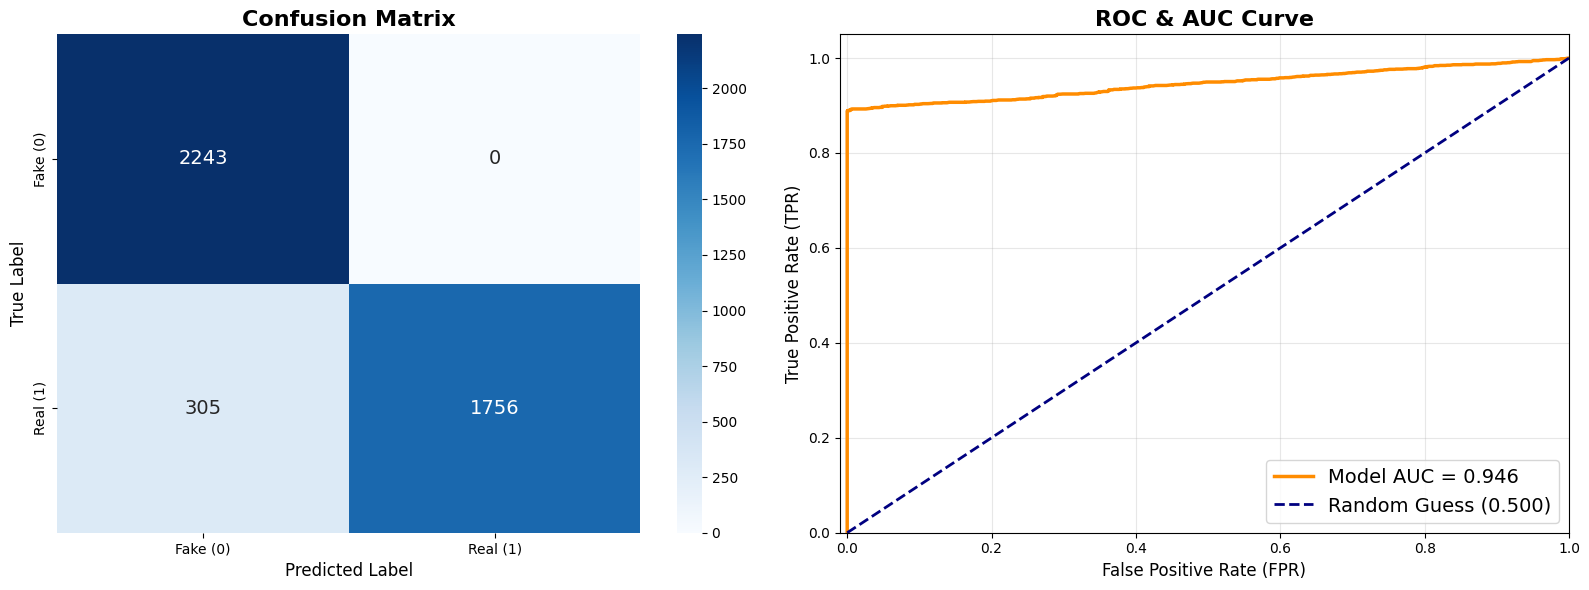

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import os

# 1. Load the results saved from your training
CSV_PATH = '/content/drive/MyDrive/deepfake_audio_research/checkpoints/final_evaluation_results.csv'

if not os.path.exists(CSV_PATH):
    print(f"File not found at {CSV_PATH}. Please check your Google Drive path!")
else:
    df = pd.read_csv(CSV_PATH)

    y_true = df['True_Label'].values
    y_prob = df['Predicted_Prob'].values
    y_pred = (y_prob > 0.5).astype(int)

    # 2. Set up a wide figure for side-by-side plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ==========================================
    # PLOT 1: CONFUSION MATRIX (Left)
    # ==========================================
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Fake (0)', 'Real (1)'],
                yticklabels=['Fake (0)', 'Real (1)'],
                annot_kws={"size": 14})
    axes[0].set_title('Confusion Matrix', fontsize=16, fontweight='bold')
    axes[0].set_xlabel('Predicted Label', fontsize=12)
    axes[0].set_ylabel('True Label', fontsize=12)

    # ==========================================
    # PLOT 2: ROC & AUC CURVE (Right)
    # ==========================================
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'Model AUC = {roc_auc:.3f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (0.500)')
    axes[1].set_xlim([-0.01, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate (FPR)', fontsize=12)
    axes[1].set_ylabel('True Positive Rate (TPR)', fontsize=12)
    axes[1].set_title('ROC & AUC Curve', fontsize=16, fontweight='bold')
    axes[1].legend(loc="lower right", fontsize=14)
    axes[1].grid(alpha=0.3)

    # 3. Save the combined plot to your Drive
    SAVE_IMG_PATH = '/content/drive/MyDrive/deepfake_audio_research/checkpoints/combined_evaluation_plots.png'
    plt.tight_layout()
    plt.savefig(SAVE_IMG_PATH, dpi=300)
    print(f"High-resolution combined plot successfully saved to: {SAVE_IMG_PATH}")

    # 4. Display the plot in Colab
    plt.show()

In [17]:
import torch
import librosa
import numpy as np
import os
import warnings

warnings.filterwarnings('ignore')

# 1. The Normalization Function (Same as training to ensure no domain shift)
def normalize_tensor(tensor):
    for c in range(tensor.size(0)):
        mean = tensor[c].mean()
        std = tensor[c].std()
        if std > 1e-6:
            tensor[c] = (tensor[c] - mean) / std
        else:
            tensor[c] = tensor[c] - mean
    return tensor

# 2. The Audio Extraction Pipeline
def process_test_audio(audio_path):
    target_samples = 16000 * 3
    # librosa can read audio directly from .mp4 or .wav files
    y, sr = librosa.load(audio_path, sr=16000, duration=3.0)

    # Pad or trim to exactly 3 seconds
    if len(y) < target_samples:
        y = np.pad(y, (0, target_samples - len(y)))
    else:
        y = y[:target_samples]

    # Generate the 3-Channels
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, hop_length=375, n_fft=1024)
    mel_db = librosa.power_to_db(mel, ref=np.max)[:, :128]

    delta1 = librosa.feature.delta(mel_db)
    delta2 = librosa.feature.delta(mel_db, order=2)

    # Stack and Normalize
    tensor = torch.tensor(np.stack([mel_db, delta1, delta2])).float()
    tensor = normalize_tensor(tensor)

    # Add the "Batch" dimension so the model sees shape: (1, 3, 128, 128)
    return tensor.unsqueeze(0)

# 3. The Inference Engine
def predict_audio_deepfake(file_path, model_path):
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load Model (Ensure your AudioDeepfakeModel class is already defined above this cell)
    model = AudioDeepfakeModel().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()

    # Process the input file
    print(f"Analyzing Audio: {os.path.basename(file_path)}...")
    input_tensor = process_test_audio(file_path).to(device)

    # Get Prediction
    with torch.no_grad():
        logits = model(input_tensor)
        prob = torch.sigmoid(logits).item()

    # Format the Output (Remember our training: Fake = 0, Real = 1)
    if prob > 0.5:
        confidence = prob * 100
        label = "REAL"
    else:
        confidence = (1 - prob) * 100
        label = "FAKE"

    print("-" * 50)
    print(f"▶Prediction : {label}")
    print(f"▶onfidence : {confidence:.2f}%")
    print("-" * 50)

    return label, confidence

# ==========================================
# TEST IT OUT HERE
# ==========================================
# Point this to your best saved model
BEST_MODEL_PATH = '/content/drive/MyDrive/deepfake_audio_research/checkpoints/best_audio_detector_v2.pth'

# Find any random .mp4 file from the Kaggle dataset you downloaded, or upload your own .wav file!
TEST_FILE = '/content/tensor_data/train/some_test_video.mp4' # <--- CHANGE THIS PATH

predict_audio_deepfake(TEST_FILE, BEST_MODEL_PATH)

In [19]:
import os
import random

# 1. We use the 'path' variable from your Kagglehub download earlier
dataset_path = path

# 2. Automatically hunt for a Real and a Fake .mp4 file
real_test_file = None
fake_test_file = None

for root, dirs, files in os.walk(dataset_path):
    for f in files:
        if f.endswith('.mp4'):
            full_path = os.path.join(root, f)
            # FakeAVCeleb separates files into RealVideo-RealAudio folders etc.
            if 'RealAudio' in full_path and not real_test_file:
                real_test_file = full_path
            elif 'FakeAudio' in full_path and not fake_test_file:
                fake_test_file = full_path

        if real_test_file and fake_test_file:
            break

print(f"Real File: {real_test_file}")
print(f"Fake File: {fake_test_file}\n")

# 3. Define the path to your trained weights
BEST_MODEL_PATH = '/content/drive/MyDrive/deepfake_audio_research/checkpoints/best_audio_detector_v2.pth'

# 4. Run the model on both!
print("==========================================")
print("TESTING A GENUINE AUDIO FILE")
print("==========================================")
predict_audio_deepfake(real_test_file, BEST_MODEL_PATH)

print("\n==========================================")
print("TESTING A DEEPFAKE AUDIO FILE")
print("==========================================")
predict_audio_deepfake(fake_test_file, BEST_MODEL_PATH)

Real File: /root/.cache/kagglehub/datasets/shreyaty08/fakeavceleb/versions/1/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/FakeVideo-RealAudio/Caucasian (American)/women/id01227/00052_id02466_wavtolip.mp4
Fake File: /root/.cache/kagglehub/datasets/shreyaty08/fakeavceleb/versions/1/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/RealVideo-FakeAudio/Caucasian (American)/women/id01227/00052_fake.mp4

TESTING A GENUINE AUDIO FILE
Analyzing Audio: 00052_id02466_wavtolip.mp4...
--------------------------------------------------
▶Prediction : REAL
▶onfidence : 100.00%
--------------------------------------------------

TESTING A DEEPFAKE AUDIO FILE
Analyzing Audio: 00052_fake.mp4...
--------------------------------------------------
▶Prediction : FAKE
▶onfidence : 93.62%
--------------------------------------------------


('FAKE', 93.6154268682003)